# ASSIGNMENT 5: Clustering and association rule mining

## Business understanding: Riikka

The main goal of this analysis is to help a drone delivery company to optimize its operations on two different areas. 

The first objective is to find the optimal locations for the company's drone depots where the drones are managed and loaded. The optimal locations should be found so that customers can be served quickly and efficiently. This is done with clustering by grouping together the customers based on their locations and finding the center coordinates of these groups. We will test and analyse how many depot locations the company should set up based on the results from modeling. We set a goal for the model as well. The clustering should be appropriate or at least reasonable, meaning the Silhouette Coefficient score should be 0.4 or over.

The second objective is to find interesting product group recommendations to increase revenue. Association rule mining provides insight to this by finding product groups that are frequently purchased from together. We will analyse which product group purchases are usually combined so the company can give recommendations for their customers based on their shopping carts and purchase histories. The goal for this objective is to find reliable rules. The confidence score of the rules should be at least 0.55.

## Part 1: Finding optimal hub locations

### Data understanding: Riikka

The client customer locations dataset was provided as a csv file. The file is stored in the datasets file of this repository. To load the file into a variable `Pandas` library has a method called `read_csv`. The `sep` parameter is used to specify the separator character for the columns since the data file uses the Finnish regional separator character, `;`, instead of the default `,`.

In [1]:
import pandas as pd

df = pd.read_csv('datasets/drone_cust_locations.csv', sep=';')
df

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298
...,...,...,...
5951,5952,832.857394,616.861410
5952,5953,242.734500,490.325092
5953,5954,108.690847,758.833921
5954,5955,803.251074,430.740623


The dataset contains 5956 samples or customers and has three columns: `clientid`, `x` and `y`. The `clientid` column contains the unique identifier for each customer. It is an integer value. The `x` column contains the x-coordinate of each client and the `y` column contains the y-coordinate of each client. The coordinates are in such a form that they can be plotted into a 2D plane. The coordinates are float values.

The customer locations are visualized with a scatterplot using the `scatterplot` function provided by the `Seaborn` library.

<Axes: xlabel='x', ylabel='y'>

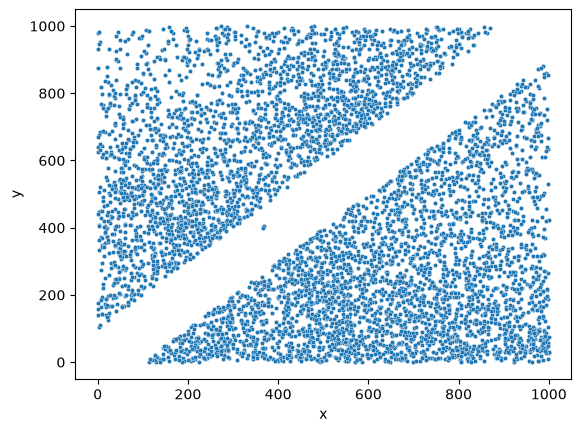

In [2]:
import seaborn as sns

sns.scatterplot(data=df, x="x", y="y", s=10)

From the scatterplot we can see that there is an empty diagonal space with a couple of customer locations on it. The rest of the customer locations are quite evenly spread on both sides of the empty space. This empty space could be a body of water, e.g. a river, or some other inhabitable space. In this analysis we make the assumption that it is a river since no general location, e.g. city, or any other explanation was provided.

### Data preparation

The `clientid` column is dropped because it is only an identifier and does not describe the customer's location. If it was left in, k-means would treat it as a third coordinate and it would distort the distances. The data has no missing values, and both `x` and `y` use the same unit and range (0–1000), so standardization is not needed either. 

In [3]:
df = df.drop(columns='clientid')
df

,x,y
0,622.771572,164.857623
1,416.357298,630.193634
2,292.735020,567.333231
3,737.211288,166.225676
4,540.475375,682.912298
...,...,...
5951,832.857394,616.861410
5952,242.734500,490.325092
5953,108.690847,758.833921
5954,803.251074,430.740623


### Modeling

The data is modeled with two clustering methods from the `sklearn` library: `KMeans` and `AgglomerativeClustering`. 

#### K-Means

The model is built with the `KMeans` class. `n_clusters` sets the number of clusters, which here is the number of depots (`n_depots`). Three depots are used as a starting point, and the number is evaluated later with the elbow method and the silhouette score. `init='random'` picks the starting centers randomly, and `random_state=42` makes the result repeatable. 

In [4]:
from sklearn.cluster import KMeans

n_depots = 3

model = KMeans(init='random', n_clusters=n_depots, random_state=42)
model.fit(df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[[70

The cluster labels and centers are saved into variables so they can be referenced later. The centers are the proposed depot locations. 

In [5]:
labels = model.labels_

centers = pd.DataFrame(model.cluster_centers_, columns=['x', 'y'])
centers

,x,y
0,702.081092,211.270383
1,198.440989,383.258618
2,548.205865,787.278896


A new dataframe is created from the labels. It shows which depot each customer belongs to. 

In [6]:
new_df = pd.DataFrame(labels, columns=['depot'])
new_df.head(10)

,depot
0,0
1,2
2,1
3,0
4,2
5,0
6,2
7,1
8,2
9,0


The label dataframe and the prepared dataframe are combined into a new `combined` dataframe, so each customer's coordinates now have a depot number.

In [7]:
combined = pd.concat([df, new_df], axis=1)
combined.head(10)

,x,y,depot
0,622.771572,164.857623,0
1,416.357298,630.193634,2
2,292.735020,567.333231,1
3,737.211288,166.225676,0
4,540.475375,682.912298,2
5,535.469492,318.439661,0
6,640.380050,870.833221,2
7,235.772075,359.048203,1
8,481.896884,661.491838,2
9,730.032789,312.177817,0


The customers are plotted and colored by depot, and the cluster centers are shown as larger orange circles. 

<Axes: xlabel='x', ylabel='y'>

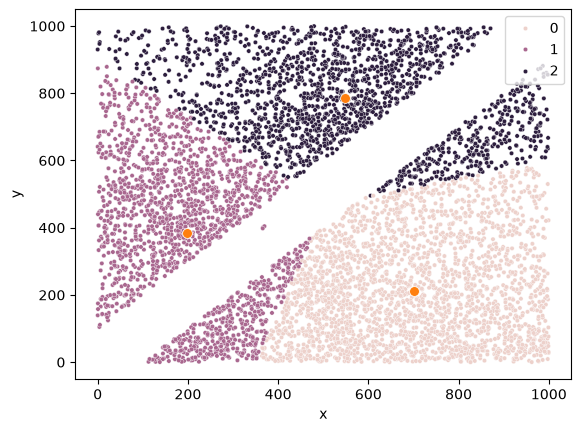

In [8]:
ax = sns.scatterplot(data=combined, x="x", y="y", s=10, hue="depot")
sns.scatterplot(data=centers, x="x", y="y", s=50, ax=ax)

With three depots, depots 1 and 2 both have customers on both sides of the river, so some deliveries would have to cross it. 

The clustering is evaluated with the inertia, also called the within-cluster sum of squared distances (WCSS). Inertia always decreases as more clusters are added, so its lowest value is not the goal. The data is clustered with k values from 1 to 10 and the inertia is plotted against k. The best k is usually found at the "elbow", where the inertia stops decreasing quickly. 

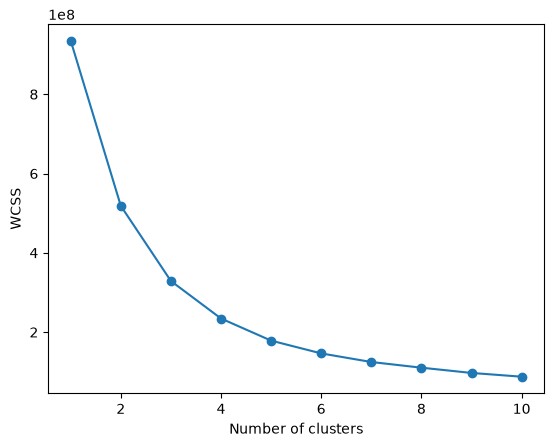

In [9]:
import matplotlib.pyplot as plt

wcss = []
for i in range(1,11):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(df)
    wcss.append(model.inertia_)
    
plt.plot(range(1,11), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

The curve does not form a sharp elbow, so the ideal number of clusters is not clear from the plot alone. The decrease seems to slow down somewhere between 3 and 5 clusters.

The silhouette score is also used. It ranges from -1 to 1: values close to 1 mean the clusters are well separated, values near 0 are borderline, and values close to -1 mean the clustering is inappropriate.

In [10]:
from sklearn.metrics import silhouette_score

print('Silhouette score = %.2f' % silhouette_score(combined, labels))

Silhouette score = 0.42


The model was run with different numbers of clusters and the results are combined in the table below:

|Clusters|Silhouette score|
|-|-|
|2|0.42|
|3|0.42|
|4|0.40|
|5|0.42|
|6|0.40|
|7|0.39|
|8|0.39|
|9|0.39|
|10|0.37|

Clusterings with 2, 3 and 5 clusters have the highest score, 0.42. This is not exceptionally strong, but it can be considered reasonable and it meets the goal of 0.4 set in the business understanding. 

To try different numbers of depots without repeating the steps above, the modeling and plotting are wrapped in a function that takes the number of depots as a parameter. 

In [11]:
# Function for modeling with k-means and plotting the clusters
def k_means_model_with_plot(clusters):
    model = KMeans(init='random', n_clusters=clusters, random_state=42)
    model.fit(df)
    
    labels = model.labels_
    centers = pd.DataFrame(model.cluster_centers_, columns=['x', 'y'])
    
    new_df = pd.DataFrame(labels, columns=['depot'])
    combined = pd.concat([df, new_df], axis=1)
    
    ax = sns.scatterplot(data=combined, x="x", y="y", s=10, hue="depot")
    sns.scatterplot(data=centers, x="x", y="y", s=50, ax=ax)

Considering the results of inertia and the silhouette scores together, 5 clusters is the best choice. It has the highest silhouette score (0.42) and is in the elbow range. 

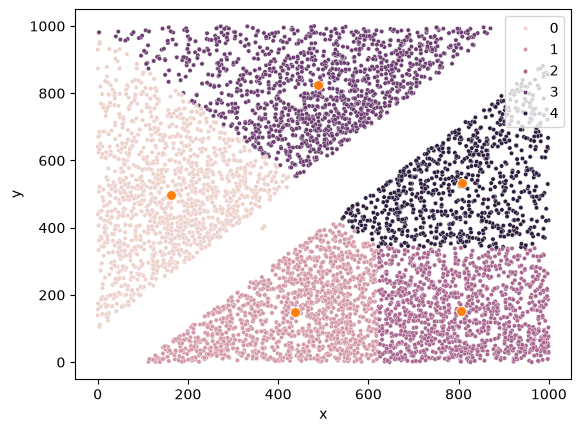

In [12]:
k_means_model_with_plot(5)

With 5 clusters, every cluster also stays on one side of the river. 

Next the model is run with 10 depots. 

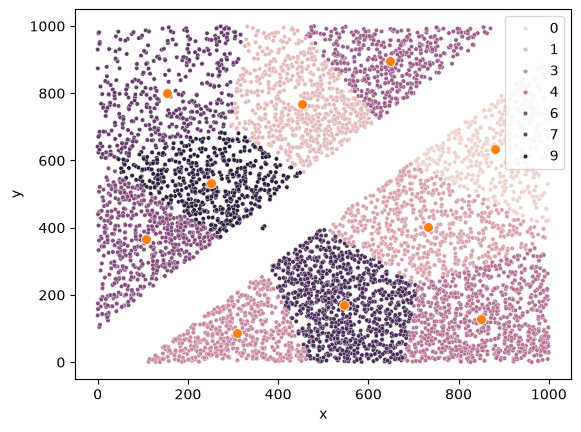

In [13]:
k_means_model_with_plot(10)

With 10 depots, every cluster stays on one side of the river and the depots are spread fairly evenly across the area. The clusters are smaller than with 5 depots, so each depot serves customers who are closer to it. 

In addition to the WCSS and the silhouette score, the computation time can also affect the decision on how many clusters to choose. It is measured with the `time` library for different numbers of depots. 

In [27]:
import time

for k in [2, 3, 4, 5, 6, 8, 10, 20, 50]:
    start = time.perf_counter()
    KMeans(init='random', n_clusters=k, random_state=42).fit(df)
    end = time.perf_counter()
    duration = round(end - start, 3)
    print(f'{k} depots: {duration} seconds')

2 depots: 0.107 seconds
3 depots: 0.094 seconds
4 depots: 0.097 seconds
5 depots: 0.098 seconds
6 depots: 0.121 seconds
8 depots: 0.14 seconds
10 depots: 0.15 seconds
20 depots: 0.264 seconds
50 depots: 0.616 seconds


The computation time grows roughly in proportion to the number of depots, except that with 2–10 depots the difference is barely noticeable. Even with 50 depots the computation time is not too high because the dataset is small and only has two features. The exact times also depend on the machine the notebook is run on. 

#### Hierarkinen: Nur

In [15]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=n_depots)
labels = model.fit_predict(df)
df['depot_hier'] = labels
#df.head(20)

In [16]:
# Silhouette Score
labels = model.labels_
print('Silhouette score = %.2f' % silhouette_score(df, labels))

Silhouette score = 0.41


scoret: 

k=4 tulos: 0.36

k=3 tulos: 0.41

k=10 tulos: 0.34

k=5 tulos: 0.37

In [17]:
# Calculate the centroids (centers) for the clusters based on the mean x and y values of the clusters. 
# Collect the centroid coordinates to an array and transform it into a dataframe.
depots2 = []

for x in range(n_depots):
    samples = df[df['depot_hier'] == x]
    depots2.append((samples['x'].mean(), samples['y'].mean()))
    
depots2_df = pd.DataFrame(depots2)
depots2_df

,0,1
0,607.735321,151.226451
1,709.978549,687.401536
2,218.178835,578.471885


<Axes: xlabel='x', ylabel='y'>

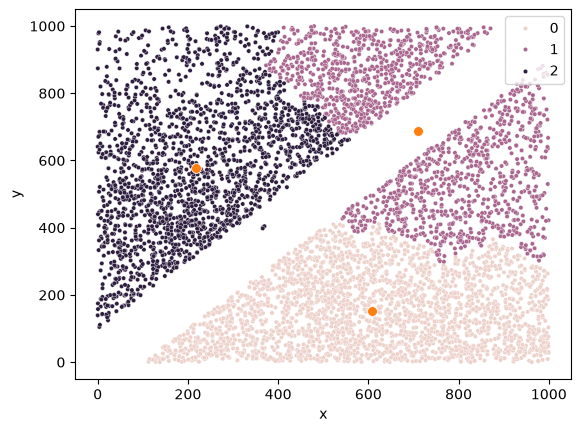

In [18]:
ax = sns.scatterplot(data=df, x="x", y="y", s=10, hue="depot_hier")
sns.scatterplot(data=depots2_df, x=0, y=1, s=50, ax=ax)

In [19]:
# kakkonen enemmän orgaanisen näköinen eli jakoi joen kohdalta puoliksi oikein, vertaa ykköseen jonka klusterit jakautuu joen molemmille puolille epätasaisesti

In [20]:
# lisää ss scatterplot k-arvoilla 4 (sekä hierarkinen että k-means)

### Evaluation: Nur

In [21]:
# vertailu
# Hierarkinen asettaa yhden clusterin keskipisteen, eli depot paikan, keskelle "jokea"

## Part 2: Finding interesting relationships between product groups

### Data understanding: Riikka

The sales data for product groups were provided in a csv file. The file is stored in the datasets file of this repository. To load the file into a variable `Pandas` library has a method called `read_csv`. The `sep` parameter is used to specify the separator character for the columns since the data file uses the Finnish regional separator character, `;`, instead of the default `,`.

In [22]:
import pandas as pd

df = pd.read_csv('datasets/drone_prod_groups.csv', sep=',')
df

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,99997,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
99997,99998,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
99998,99999,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1


The dataset contains 100 000 samples or transactions and has 21 columns. The `ID` column contains the unique identifier of each transaction in an integer value. The similarly named columns from `Prod1` to `Prod20` represent different product groups or categories. They are binary variables. Value of 1 indicates that at least one product from the group was purchased in the transaction and value of 0 indicates that no products from the group was purchased in the transaction.

### Data preparation: Anni

First, the id column is dropped, as it is not needed for the analysis.

Since the chosen algorithm requires the data to be in a specific format, the binary values are converted into boolean values. The 0 values are replaced with False and 1 values with True.

In [23]:
df = df.drop(columns='ID')

df = df.astype(bool)
df

,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,Prod10,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True
3,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
99997,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
99998,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True


The dataset is ready for the modeling phase, since the dataframe contains only boolean values.

### Modeling: Anni

The Apriori algorithm is a popular algorithm used in association rule mining tasks to find interesting relationships between product groups. The algorithm proceeds in two phases: finding all frequent itemsets and generating association rules based on the found sets. 

The quality of the association rules is evaluated using two metrics: support and confidence. Support measures the proportion of transactions in the dataset that contain the itemset. Confidence measures the reliability of the rule. 

The model is built using the `apriori` and `association_rules` methods provided by `mlxtend`. 
In the first phase, the algorithm finds all frequent item sets. This is done by eliminating the itemsets that do not reach the chosen minimum support threshold defined as the hyperparameter `min_support`. 

Since the dataset contains a rather large number of possible itemsets, the minimum support threshold is set to 0.03 (3%). 

In [24]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

frequent_itemsets = apriori(df, min_support=0.03, use_colnames=True)

The itemsets after filtering:

In [25]:
frequent_itemsets

,support,itemsets
0,0.10998,frozenset({Prod1})
1,0.13098,frozenset({ Prod2})
2,0.03271,frozenset({ Prod3})
3,0.03585,frozenset({ Prod4})
4,0.10459,frozenset({ Prod5})
5,0.13499,frozenset({ Prod7})
6,0.16179,frozenset({ Prod8})
7,0.19853,frozenset({ Prod9})
8,0.09336,frozenset({ Prod10})
9,0.10848,frozenset({ Prod11})


In the second part of the algorithm, the association rules are generated from the frequent itemsets. The association rules are selected after generating all possible combinations. The rules that do not meet the minimum confidence threshold of 0.55 are filtered out.

The hyperparameter `min_threshold` sets the threshold for an association rule to be considered interesting.

In [26]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.55)

rules = rules.sort_values(by='confidence', ascending=False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,frozenset({ Prod15}),frozenset({ Prod9}),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
3,frozenset({ Prod20}),frozenset({ Prod19}),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
6,"frozenset({ Prod9, Prod20})",frozenset({ Prod19}),0.03676,0.20626,0.03345,0.909956,4.411696,1.0,0.025868,8.815070,0.802842,0.159613,0.886558,0.536065
5,"frozenset({ Prod9, Prod19})",frozenset({ Prod20}),0.04996,0.14798,0.03345,0.669536,4.524501,1.0,0.026057,2.578251,0.819946,0.203356,0.612140,0.447790
4,frozenset({ Prod19}),frozenset({ Prod20}),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
0,frozenset({ Prod5}),frozenset({ Prod12}),0.10459,0.15971,0.06683,0.638971,4.000822,1.0,0.050126,2.327488,0.837662,0.338431,0.570352,0.528709
2,frozenset({ Prod9}),frozenset({ Prod15}),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754


The result shows seven association rules in decreasing order of confidence. The `antecedents` represent the initial category/categories, and the `consequents` represent the category to be recommended. All confidences are greater than 55%.

The strongest relationships can be found in the first three rows with confidence over 0.9 (90%).

The rows numbered 4 and 3 both contain the same product groups (Prod20 and Prod19). Prod19 will be bought together with Prod20 91% of the time. The confidence is considerably greater than the confidence of Prod20 being bought together with Prod19, which is 65%. Presumably, Prod19 is commonly bought together with different categories as well.

### Evaluation: Anni

The seven association rules are qualified based on a support of 0.03 and a confidence of 0.55.

To increase revenue, the company should focus on the product groups listed in the result. Based on the findings, product groups under `antecedents` act as a trigger to buy from the groups under `consequents`. Therefore, the company should recommend the consequent product group in situations where the buyer is purchasing from the antecedent category.

## Deployment: Riikka


The clustering model works well for finding general locations for the depots but whether these are valid locations for stationing and managing drones cannot be decided with results alone. The company needs to critically analyse the results, do research and make the final decisions. With the model the company can also analyse how many depots they should set up to optimize their operations especially if they decide to expand their service area.

The association rule mining can help the company to create product bundles and to give product recommendations for their customers. The rules found in this analysis can be used for this. The company should do a new analysis as they gather more transaction data to provide the customers more accurate recommendations.